# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

## Business Problem:

A used-car marketplace or dealership wants to better understand what factors most strongly influence the selling price of used vehicles. The goal is to improve pricing accuracy, identify high-value vehicle characteristics, forecast future pricing behavior, and support better inventory, purchasing, and sales decisions.

This can help the business:

* Price vehicles competitively (Main focus)
* Avoid underpricing or overpaying for inventory (Secondary focus)
* Predict depreciation trends (Secondary focus)
* Understand market demand patterns (Secondary focus)
* Improve profitability and turnover rates (Secondary focus)

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

## Framing as a Data Science / ML Problem
From a data science perspective, this task can be framed as a supervised machine learning regression problem, where the objective is to model and predict a continuous target variable — the used car sale price — using various vehicle attributes and market-related features.

The dataset will be analyzed to:

Perform Exploratory Data Analysis (EDA) to understand distributions, correlations, missing values, outliers, and relationships between variables.
Apply Feature Engineering techniques to transform raw vehicle attributes into more informative predictors.
Train and evaluate multiple regression models (e.g., linear regression, polynomial regression, regularized models) to estimate vehicle prices.
Investigate bias-variance tradeoffs, overfitting, underfitting, and model generalization performance.
Use feature selection and regularization techniques (such as Lasso and Ridge) to identify the most influential predictors and reduce model complexity.
Explore time series forecasting methods to analyze how used car prices evolve over time and forecast future market trends.
The overall analytical objective is to identify the key drivers of used car prices while developing predictive models that generalize well to unseen data and provide interpretable business insights.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [8]:
# 1. Load Data
# -------------------------

vehicles = pd.read_csv("/Users/rt-mac/Documents/ml_projects/CarSalesPredictor/data/vehicles.csv")
print("Dataset shape:", vehicles.shape)
display(vehicles.head())
display(vehicles.info())

Dataset shape: (426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

None

In [11]:
display(vehicles.describe(include="all").T)

# Missing values
missing = (
    vehicles.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

missing["missing_percent"] = missing["missing_count"] / len(vehicles) * 100

display(missing)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,"426,880.00",NaN,NaN,NaN,"7,311,486,634.22","4,473,170.41","7,207,408,119.00","7,308,143,339.25","7,312,620,821.00","7,315,253,543.50","7,317,101,084.00"
region,426880,404,columbus,3608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,"426,880.00",NaN,NaN,NaN,"75,199.03","12,182,282.17",0.00,"5,900.00","13,950.00","26,485.75","3,736,928,711.00"
year,"425,675.00",NaN,NaN,NaN,"2,011.24",9.45,"1,900.00","2,008.00","2,013.00","2,017.00","2,022.00"
manufacturer,409234,42,ford,70985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,421603,29649,f-150,8009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,252776,6,good,121456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cylinders,249202,8,6 cylinders,94169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel,423867,5,gas,356209,NaN,NaN,NaN,NaN,NaN,NaN,NaN
odometer,"422,480.00",NaN,NaN,NaN,"98,043.33","213,881.50",0.00,"37,704.00","85,548.00","133,542.50","10,000,000.00"


,missing_count,missing_percent
size,306361,71.77
cylinders,177678,41.62
condition,174104,40.79
VIN,161042,37.73
drive,130567,30.59
paint_color,130203,30.50
type,92858,21.75
manufacturer,17646,4.13
title_status,8242,1.93
model,5277,1.24


In [12]:
# Duplicate rows
print("Duplicate rows:", vehicles.duplicated().sum())

Duplicate rows: 0


In [18]:
#check basic stats for price and odometer:
print(vehicles[["price", "odometer"]].describe())
print(vehicles[["price", "odometer"]].skew())

                 price      odometer
count       426,880.00    422,480.00
mean         75,199.03     98,043.33
std      12,182,282.17    213,881.50
min               0.00          0.00
25%           5,900.00     37,704.00
50%          13,950.00     85,548.00
75%          26,485.75    133,542.50
max   3,736,928,711.00 10,000,000.00
price      254.41
odometer    38.04
dtype: float64


Original shape: (426880, 16)
Filtered shape: (374786, 16)
           price   odometer
count 374,786.00 374,786.00
mean   19,166.89  92,929.98
std    14,304.68  61,501.87
min       500.00     100.00
25%     7,900.00  39,649.00
50%    15,950.00  88,168.00
75%    27,990.00 135,593.75
max   100,000.00 300,000.00
price      1.23
odometer   0.52
dtype: float64


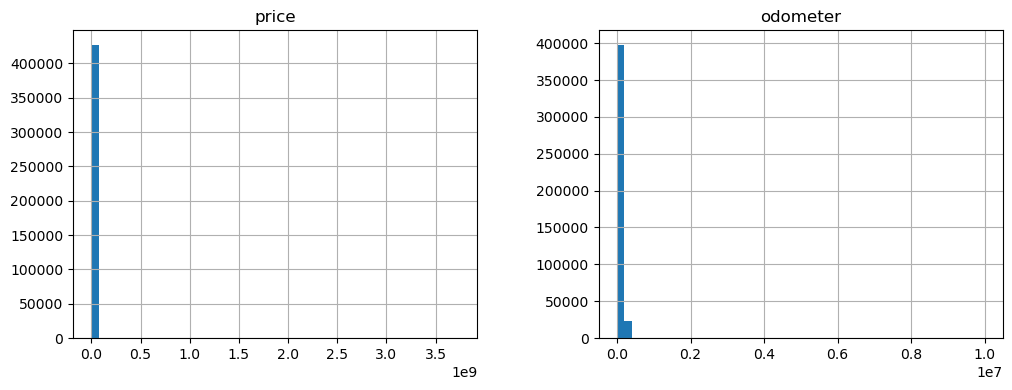

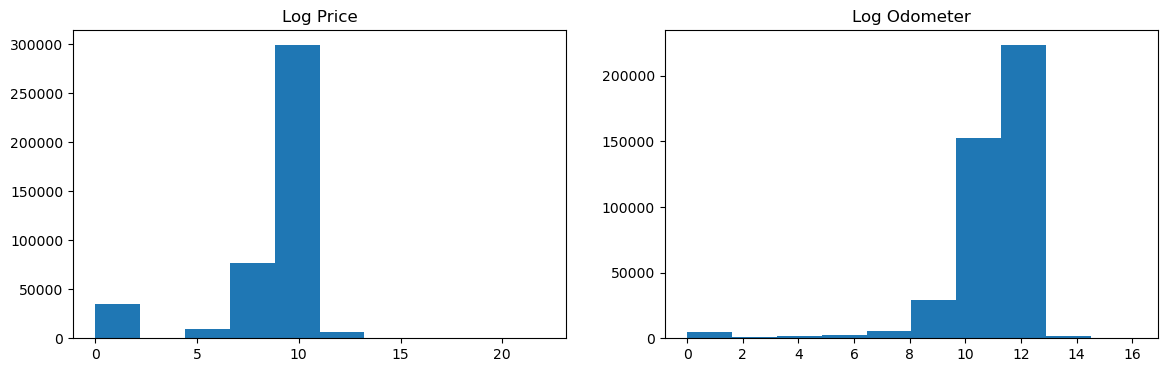

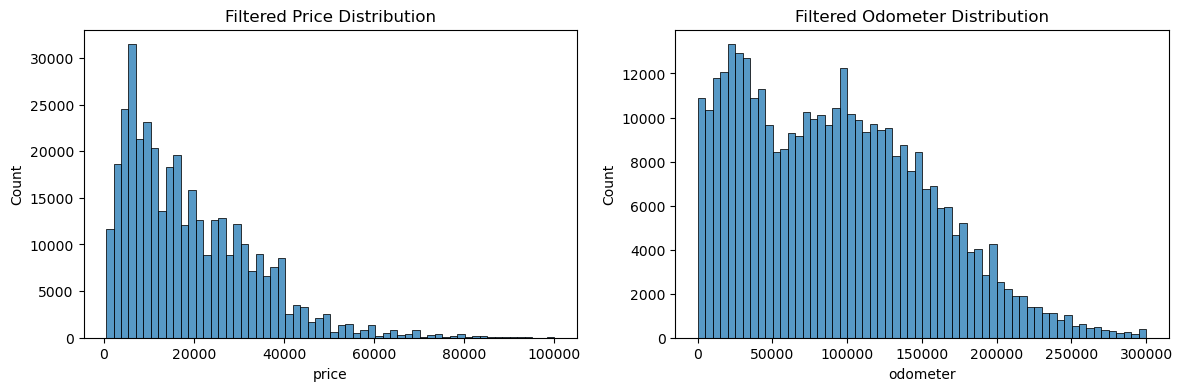

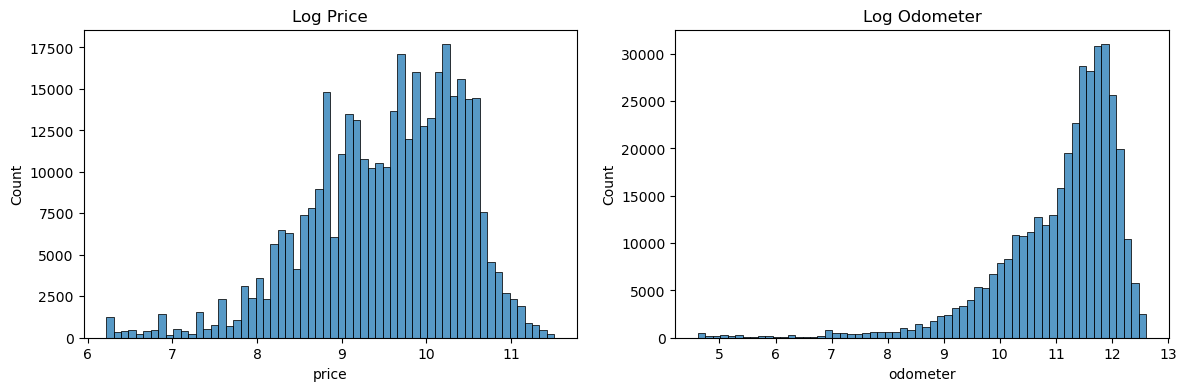

In [31]:
# Data Cleaning

# Drop variables that are both extremely sparse and low business value: Size and VIN
vehicles_clean = vehicles.copy()
vehicles_clean = vehicles_clean.drop(columns=["size", "VIN"])

# Fill relevant categorical varaibles with "unknown" (more conversion to numeric values comes later). 
# (cntd): These variables may reprsent some valuable context about the car: condition, cylinders, drive, paint_color and type
categorical_cols = vehicles_clean.select_dtypes(include="object").columns

for col in categorical_cols:
    vehicles_clean[col] = vehicles_clean[col].fillna("Unknown")


# Car pricess and Odometer looks highly skewed ==> fix a bound and adjust the outliers or extreme values
vehicles_clean[["price", "odometer"]].hist(
    figsize=(12, 4),
    bins=50
);

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].hist(np.log1p(vehicles_clean["price"]))
ax[0].set_title("Log Price")
ax[1].hist(np.log1p(vehicles_clean["odometer"]))
ax[1].set_title("Log Odometer");

vehicles_filtered = vehicles_clean.query(
    "500 <= price <= 100000 and 100 <= odometer <= 300000"
).copy()

print("Original shape:", vehicles_clean.shape)
print("Filtered shape:", vehicles_filtered.shape)

#Again, check stats for price and odometer:
print(vehicles_filtered[["price", "odometer"]].describe())
print(vehicles_filtered[["price", "odometer"]].skew())

#visualize
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(vehicles_filtered["price"], bins=60, ax=ax[0])
ax[0].set_title("Filtered Price Distribution")
sns.histplot(vehicles_filtered["odometer"], bins=60, ax=ax[1])
ax[1].set_title("Filtered Odometer Distribution")
plt.show()

# log transform visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(np.log1p(vehicles_filtered["price"]), bins=60, ax=ax[0])
ax[0].set_title("Log Price")
sns.histplot(np.log1p(vehicles_filtered["odometer"]), bins=60, ax=ax[1])
ax[1].set_title("Log Odometer")

plt.show()


In [32]:
# Verify remaining missing values

remaining_missing = vehicles_filtered.isna().sum()
display(
    remaining_missing[remaining_missing > 0]
)

print("Final shape:", vehicles_filtered.shape)

year    973
dtype: int64

Final shape: (374786, 16)


In [33]:
# Year is missing for 973/374786 = 0.26% of records. 
# In case if we decide to use the year for calculating how old the car is, it maybe good to keep this variable and drop the missing rec
# Alternate option i considered was to replace missing year with median of year, but I felt it may bias the dataset 
# (ctnd) unless i spend more time cross tabulating to see if there is sub segment of cars that have missing year 
# (cntn) to create any further derived variables

vehicles_filtered = vehicles_filtered.dropna(subset=["year"])

# Verify remaining missing values

remaining_missing = vehicles_filtered.isna().sum()
display(
    remaining_missing[remaining_missing > 0]
)

print("Final shape:", vehicles_filtered.shape)


Series([], dtype: int64)

Final shape: (373813, 16)


In [35]:
vehicles_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 373813 entries, 27 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            373813 non-null  int64  
 1   region        373813 non-null  object 
 2   price         373813 non-null  int64  
 3   year          373813 non-null  float64
 4   manufacturer  373813 non-null  object 
 5   model         373813 non-null  object 
 6   condition     373813 non-null  object 
 7   cylinders     373813 non-null  object 
 8   fuel          373813 non-null  object 
 9   odometer      373813 non-null  float64
 10  title_status  373813 non-null  object 
 11  transmission  373813 non-null  object 
 12  drive         373813 non-null  object 
 13  type          373813 non-null  object 
 14  paint_color   373813 non-null  object 
 15  state         373813 non-null  object 
dtypes: float64(2), int64(2), object(12)
memory usage: 48.5+ MB


# So far, dropped irrelevant , removed outliers, handled missing values. Moving on to Feature engineering

# Feature Engineering

Some of the remaining variables need to be transformed to get a better value out of them:

For example:

Year --> car_age, 
odometer --> odometer_per_year, 
manufacturer --> luxury_brand, 
state --> regional grouping, 
cylinders --> numeric cyliner count (higher number indicate higher engine power), 
condition --> ordinal quality score



In [37]:
#get frequency count of variables as needed

def frequency_table(df, columns):
    for col in columns:
        freq_table = pd.DataFrame({
            "count": df[col].value_counts(),
            "percent": df[col].value_counts(normalize=True) * 100
        })
        print(f"\n===== {col.upper()} =====")
        display(freq_table)

# Check for what values condition, manufacturer and cylinders take, so as to make decisions about transformations

frequency_table(
    vehicles_filtered,
    ["condition", "manufacturer", "cylinders"]
)




===== CONDITION =====


,count,percent
condition,,
Unknown,140379,37.55
good,116897,31.27
excellent,89789,24.02
like new,19293,5.16
fair,6223,1.66
new,724,0.19
salvage,508,0.14



===== MANUFACTURER =====


,count,percent
manufacturer,,
ford,62222,16.65
chevrolet,47982,12.84
toyota,30322,8.11
honda,19093,5.11
nissan,16691,4.47
jeep,16527,4.42
ram,15782,4.22
gmc,14865,3.98
bmw,13184,3.53



===== CYLINDERS =====


,count,percent
cylinders,,
Unknown,152124,40.70
6 cylinders,84687,22.65
4 cylinders,68932,18.44
8 cylinders,63736,17.05
5 cylinders,1607,0.43
10 cylinders,1086,0.29
other,949,0.25
3 cylinders,540,0.14
12 cylinders,152,0.04


In [46]:
cars = vehicles_filtered.copy()

# condition of car mapped to ordered numeric variable
condition_map = {
    "salvage": 0,
    "fair": 1,
    "good": 2,
    "excellent": 3,
    "like new": 4,
    "new": 5,
    "unknown": -1
}

cars["condition_score"] = (
    cars["condition"]
    .str.lower()
    .map(condition_map)
)

# extract number of cylinders
# if values missing create another variable (1 or 0) if data is missing
# fill missing values with -1 value, because the model might learn that -1 indicates missing data!
# There is a chance cylinder data missing might indicate something about perception of consumers

cars["cylinders_missing"] = (
    cars["cylinders"]
    .isin(["Unknown", "other"])
    .astype(int)
)
cars["cylinders_numeric"] = (
    cars["cylinders"]
    .str.extract(r"(\d+)")
    .astype(float)
)
cars["cylinders_numeric"] = (
    cars["cylinders_numeric"]
    .fillna(-1)
)

#create indication for luxury car brands
luxury_brands = [
    "bmw",
    "mercedes-benz",
    "audi",
    "lexus",
    "porsche",
    "jaguar",
    "cadillac",
    "infiniti",
    "acura",
    "lincoln"
]

cars["is_luxury"] = (
    cars["manufacturer"]
    .str.lower()
    .isin(luxury_brands)
    .astype(int)
)

# Create derived varaible car age
cars["car_age"] = 2026 - cars["year"]

# Milage per year to get an average usage (indirect indication of depreciation vs usage)
odometer_per_year = (
    cars["odometer"]
    .div(cars["car_age"].replace(0, np.nan))
)
cars["odometer_per_year"] = (
    odometer_per_year.fillna(
        odometer_per_year.median()
    )
)


#check how it looks

display(
    cars[
        [
            "car_age",
            "odometer",
            "odometer_per_year",
            "condition_score",
            "cylinders_numeric",
            "is_luxury"
        ]
    ].head()
)

,car_age,odometer,odometer_per_year,condition_score,cylinders_numeric,is_luxury
27,12.00,"57,923.00","4,826.92",2,8.00,0
28,16.00,"71,229.00","4,451.81",2,8.00,0
29,6.00,"19,160.00","3,193.33",2,8.00,0
30,9.00,"41,124.00","4,569.33",2,8.00,0
31,13.00,"128,000.00","9,846.15",3,6.00,0


,count,mean,std,min,25%,50%,75%,max
car_age,"373,813.00",14.90,9.28,4.00,9.00,13.00,18.00,126.00
odometer_per_year,"373,813.00","6,424.62","3,624.18",0.80,"3,666.12","6,289.20","8,750.00","60,000.00"
condition_score,"373,813.00",1.20,1.80,-1.00,-1.00,2.00,3.00,5.00
cylinders_numeric,"373,813.00",3.11,3.64,-1.00,-1.00,4.00,6.00,12.00
cylinders_missing,"373,813.00",0.41,0.49,0.00,0.00,0.00,1.00,1.00
is_luxury,"373,813.00",0.16,0.37,0.00,0.00,0.00,0.00,1.00


,skewness
car_age,3.43
odometer_per_year,0.58
condition_score,-0.21
cylinders_numeric,-0.03
cylinders_missing,0.37
is_luxury,1.84


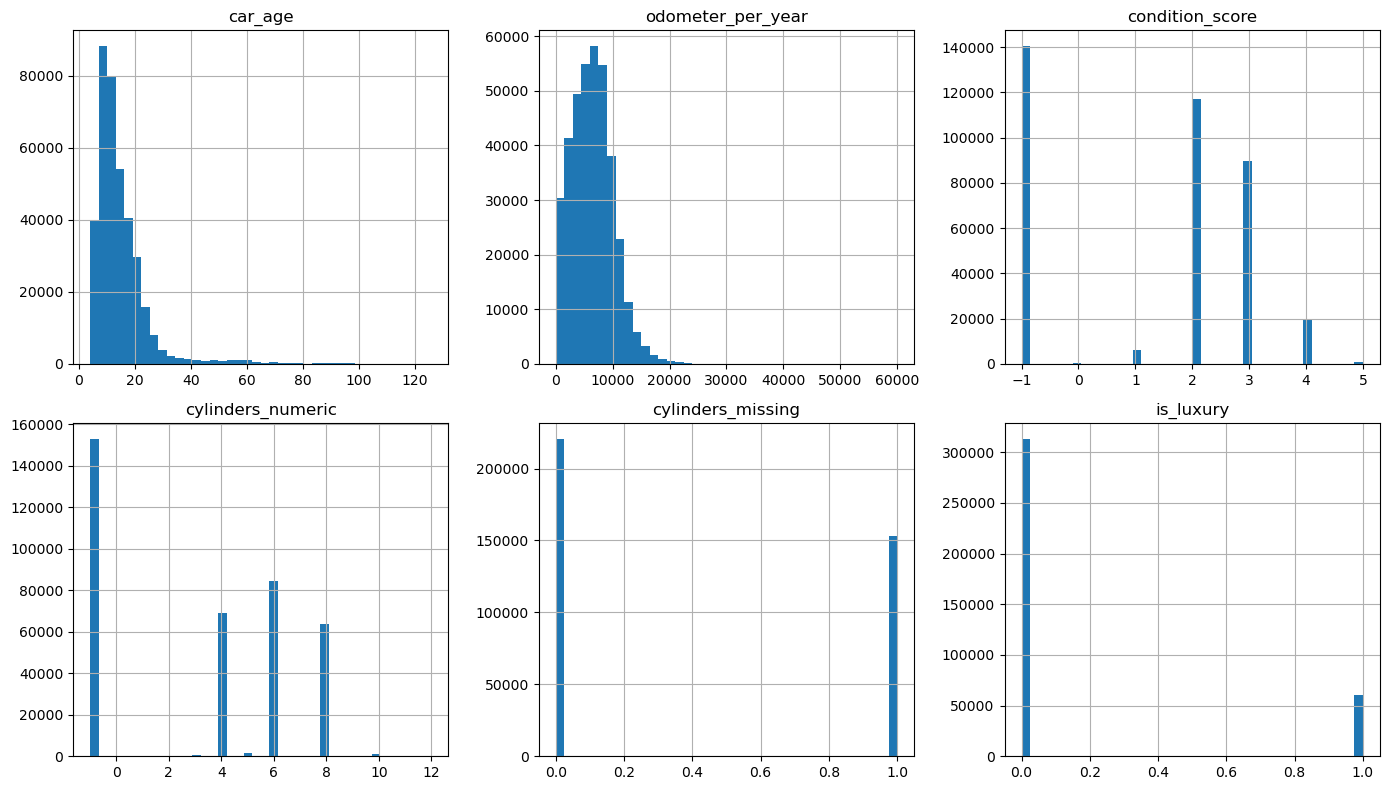

In [47]:
# Lets review these newly engineered features

engineered_features = [
    "car_age",
    "odometer_per_year",
    "condition_score",
    "cylinders_numeric",
    "cylinders_missing",
    "is_luxury"
]

#Descriptive Statistics

display(
    cars[engineered_features]
    .describe()
    .T
)

#check skewness to decide if any further transformation ins needed; and review histogram
skew_table = pd.DataFrame({
    "skewness": cars[engineered_features].skew()
})

display(skew_table)
cars[engineered_features].hist(
    figsize=(14, 8),
    bins=40,
    layout=(2, 3)
);
plt.tight_layout()



In [50]:
# car age seems to have unrealistic max value of 126 years. So, filtering out any cars that are > 50 years old

cars = cars.query("1976 <= year <= 2026")

cars.describe()

,id,price,year,odometer,condition_score,cylinders_missing,cylinders_numeric,is_luxury,car_age,odometer_per_year
count,"367,848.00","367,848.00","367,848.00","367,848.00","367,848.00","367,848.00","367,848.00","367,848.00","367,848.00","367,848.00"
mean,"7,311,462,560.19","19,109.23","2,011.91","93,725.41",1.20,0.41,3.09,0.16,14.09,"6,514.30"
std,"4,391,844.75","14,213.71",6.63,"61,543.75",1.80,0.49,3.63,0.37,6.63,"3,582.61"
min,"7,301,583,321.00",500.00,"1,976.00",100.00,-1.00,0.00,-1.00,0.00,4.00,2.00
25%,"7,308,061,832.00","7,900.00","2,008.00","40,166.00",-1.00,0.00,-1.00,0.00,9.00,"3,802.12"
50%,"7,312,553,598.50","15,900.00","2,013.00","89,292.00",2.00,0.00,4.00,0.00,13.00,"6,372.20"
75%,"7,315,239,068.75","27,990.00","2,017.00","136,585.00",3.00,1.00,6.00,0.00,18.00,"8,795.91"
max,"7,317,101,084.00","100,000.00","2,022.00","300,000.00",5.00,1.00,12.00,1.00,50.00,"60,000.00"


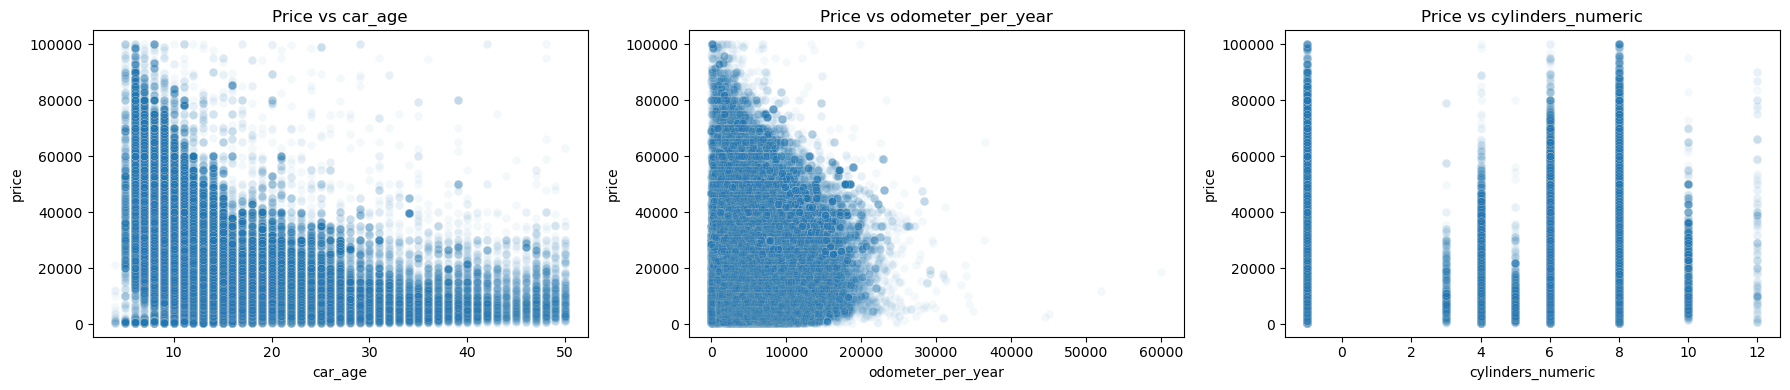

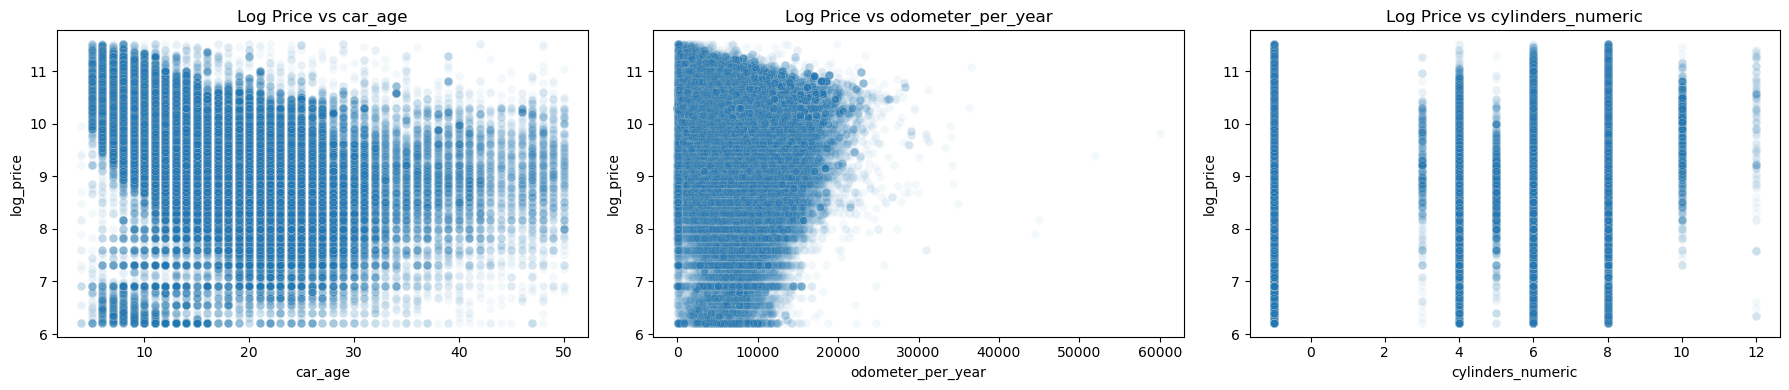

In [55]:
# Price has some very high value ==> Creating log of price so that numeric features can be analyzed against both price and log of price
cars["log_price"] = np.log1p(cars["price"])

# Scatterplots for continuous features
continuous_features = [
    "car_age",
    "odometer_per_year",
    "cylinders_numeric"
]

# Scatter plot PRICE
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, continuous_features):
    sns.scatterplot(
        data=cars,
        x=col,
        y="price",
        alpha=0.05,
        ax=ax
    )
    ax.set_title(f"Price vs {col}")

plt.tight_layout()
plt.show()

# Scatter plot LOG of PRICE
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, continuous_features):
    sns.scatterplot(
        data=cars,
        x=col,
        y="log_price",
        alpha=0.05,
        ax=ax
    )
    ax.set_title(f"Log Price vs {col}")

plt.tight_layout()
plt.show()


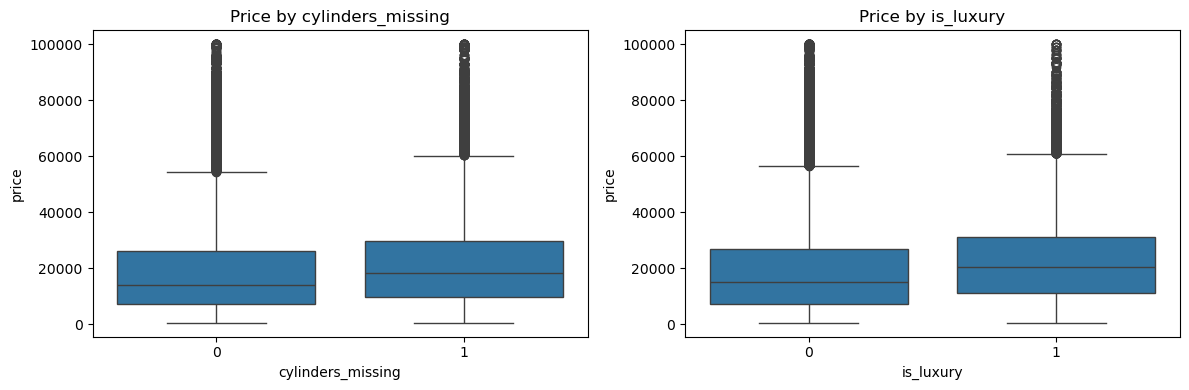

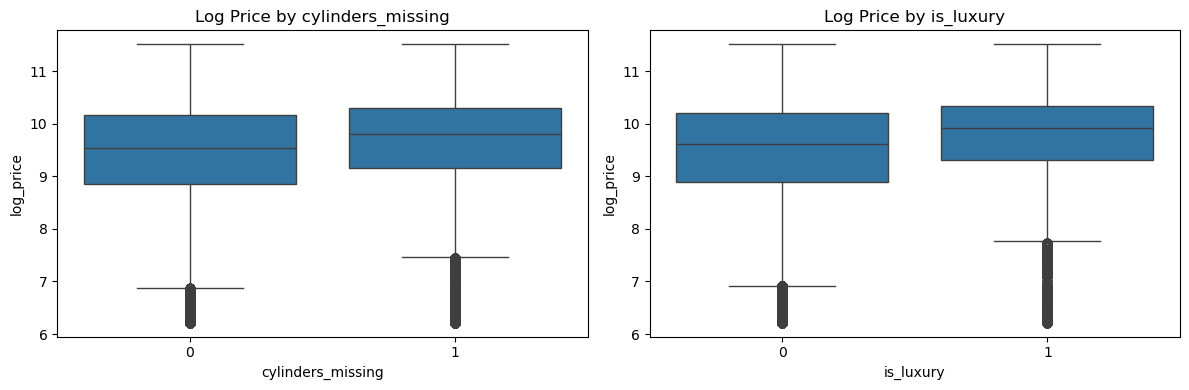

In [57]:
# Binary/Categorical Features

binary_features = [
    "cylinders_missing",
    "is_luxury"
]

# Boxplots for Binary / Categorical Features

# with PRICE

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, binary_features):
    sns.boxplot(
        data=cars,
        x=col,
        y="price",
        ax=ax
    )
    ax.set_title(f"Price by {col}")

plt.tight_layout()
plt.show()

# with LOG of PRICE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, binary_features):
    sns.boxplot(
        data=cars,
        x=col,
        y="log_price",
        ax=ax
    )
    ax.set_title(f"Log Price by {col}")

plt.tight_layout()
plt.show()



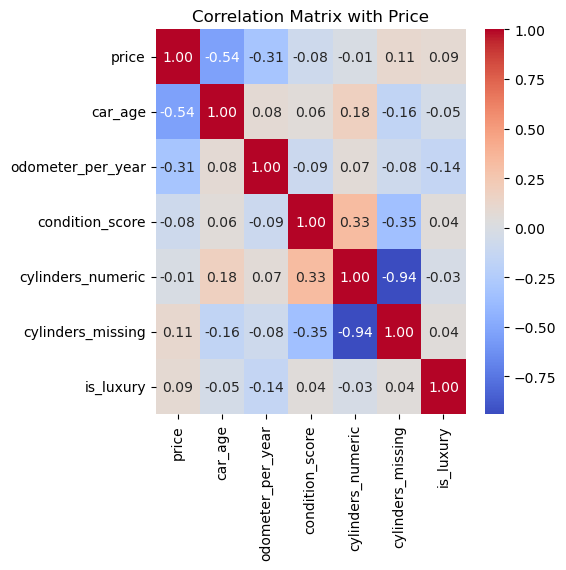

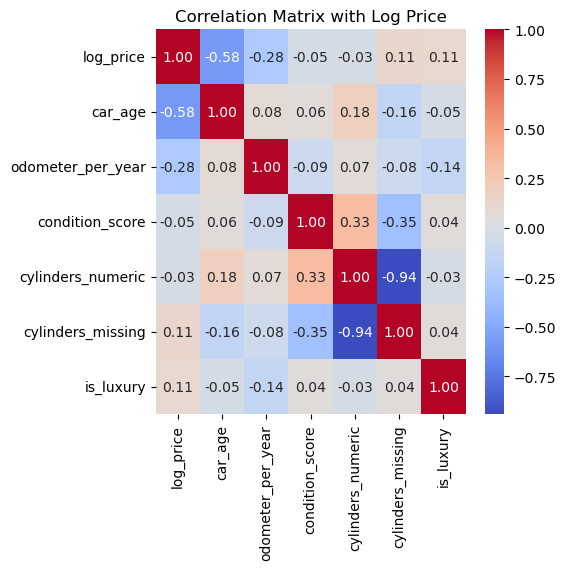

In [61]:
# Heatmap of Correlation Matrix with Raw Price

analysis_cols = [
    "price",
    "car_age",
    "odometer_per_year",
    "condition_score",
    "cylinders_numeric",
    "cylinders_missing",
    "is_luxury"
]

plt.figure(figsize=(5, 5))

sns.heatmap(
    cars[analysis_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix with Price")
plt.show()

# Heatmap of Correlation Matrix with LOG of Price

analysis_cols_log = [
    "log_price",
    "car_age",
    "odometer_per_year",
    "condition_score",
    "cylinders_numeric",
    "cylinders_missing",
    "is_luxury"
]

plt.figure(figsize=(5, 5))

sns.heatmap(
    cars[analysis_cols_log].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix with Log Price")
plt.show()


In [62]:
cars["condition_score"].isna().sum()

np.int64(0)

In [63]:
cars.groupby("condition")["price"].median()

condition
Unknown     16,291.00
excellent   11,990.00
fair         2,600.00
good        21,000.00
like new    14,900.00
new         16,900.00
salvage      2,000.00
Name: price, dtype: float64

In [64]:
# Changing the condition_numeric variable's "unknown" to be muted with Median value because of the above results, 
# (cntd) which shows the relationship is not monotonic

cars["cylinders_numeric"] = (
    cars["cylinders"]
    .str.extract(r"(\d+)")
    .astype(float)
)

cars["cylinders_missing"] = (
    cars["cylinders_numeric"]
    .isna()
    .astype(int)
)

cars["cylinders_numeric"] = (
    cars["cylinders_numeric"]
    .fillna(
        cars["cylinders_numeric"].median()
    )
)


## Final EDA Summary

# Dataset Cleaning Summary

* Removed extreme outliers in price and odometer, significantly reducing skewness and improving statistical stability.
* Dropped sparse low-business-value variables (size, VIN) while preserving potentially informative categorical features.
* Preserved categorical missingness using "Unknown" to retain possible business signal.

# Engineered Feature Summary

car_age: Strong negative relationship with price/log_price, indicating vehicle age is one of the strongest depreciation predictors.

odometer_per_year: Moderate negative relationship with pricing, suggesting annual usage intensity meaningfully contributes to depreciation.

condition_score: Weak and inconsistent correlation with pricing, likely due to noisy marketplace condition labels and inconsistent seller behavior.

cylinders_numeric: Minimal linear relationship with price, suggesting cylinder count alone does not strongly explain pricing across brands and vehicle types.

cylinders_missing: Highly correlated with cylinders_numeric, indicating potential multicollinearity; however, missingness itself may still contain predictive signal.

is_luxury: Luxury vehicles show consistently higher median pricing distributions, although linear correlation remains modest.

# Target Variable Summary

* Raw price remains right-skewed even after cleaning.
* log_price exhibits improved variance stability and more linear-looking relationships with predictors.
* Visual analysis suggests log_price is likely a better target for regression modeling.


# Dataset now appears sufficiently clean and structured for baseline regression modeling and feature-selection analysis

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [67]:
# Feature set - numeric and categorical

numeric_features = [
    "car_age",
    "odometer_per_year",
    "condition_score",
    "cylinders_numeric",
    "is_luxury"
]

categorical_features = [
    "manufacturer",
    "fuel",
    "transmission",
    "drive",
    "type",
    "paint_color",
    "title_status",
    "state"
]

# Define X and y ==> Creating a log of price as y based on EDA insights
X = cars[
    numeric_features + categorical_features
]
y = cars["log_price"]

# Spliting test and training datasets, keeping 80% for trianing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.head(5))
print(y_train.head(5))


        car_age  odometer_per_year  condition_score  cylinders_numeric  \
174669    10.00          12,396.10               -1               6.00   
63868     11.00          16,721.64                3               8.00   
287650    12.00          12,750.00                2               6.00   
185793    12.00           2,487.08                2               6.00   
66739     29.00           7,827.59                2               4.00   

        is_luxury   manufacturer   fuel transmission    drive     type  \
174669          0          dodge  other    automatic  Unknown  Unknown   
63868           0        Unknown    gas    automatic  Unknown      van   
287650          0      chevrolet    gas    automatic  Unknown  Unknown   
185793          1  mercedes-benz  other    automatic  Unknown    coupe   
66739           0          honda    gas    automatic      fwd    wagon   

       paint_color title_status state  
174669     Unknown        clean    la  
63868        white        clea

In [68]:
# Build a pipe to preprocess features
# SCALE the numeric columns to standard distribution to bring regularization and stability
# HOTCODE the catagorical varaibles to be used as effective features as binary indicators

from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

preprocessor = make_column_transformer(
    (
        StandardScaler(),
        numeric_features
    ),
    (
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features
    )
)


In [69]:
# Linear Regression Pipeline

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

baseline_model = Pipeline([  
    ("preprocessor", preprocessor),    
    ("linreg", LinearRegression())
])


In [70]:
# Fit and Predict

baseline_model.fit(X_train, y_train)

train_preds = baseline_model.predict(X_train)
test_preds = baseline_model.predict(X_test)


In [71]:
# Train vs Test
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

train_rmse = np.sqrt(
    mean_squared_error(y_train, train_preds)
)
test_rmse = np.sqrt(
    mean_squared_error(y_test, test_preds)
)

train_r2 = r2_score(y_train, train_preds)
test_r2 = r2_score(y_test, test_preds)

# print metrics

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

print("Train R²:", train_r2)
print("Test R²:", test_r2)


Train RMSE: 0.5574746039958461
Test RMSE: 0.5575919996725314
Train R²: 0.609773761908796
Test R²: 0.60728808421774


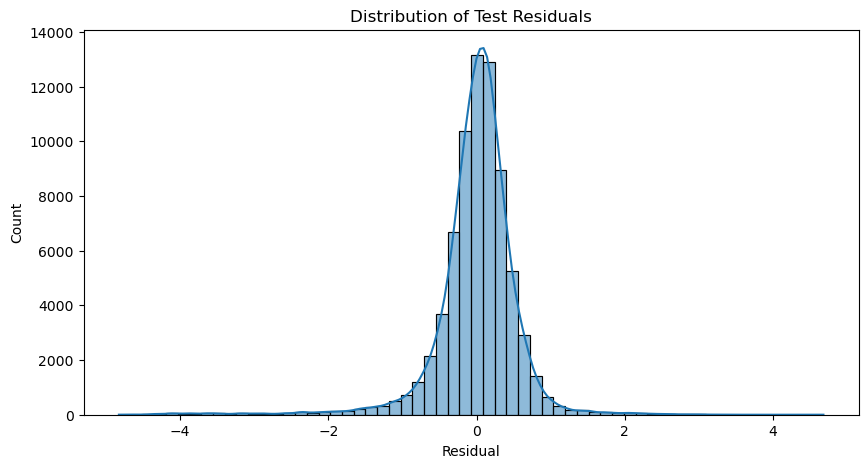

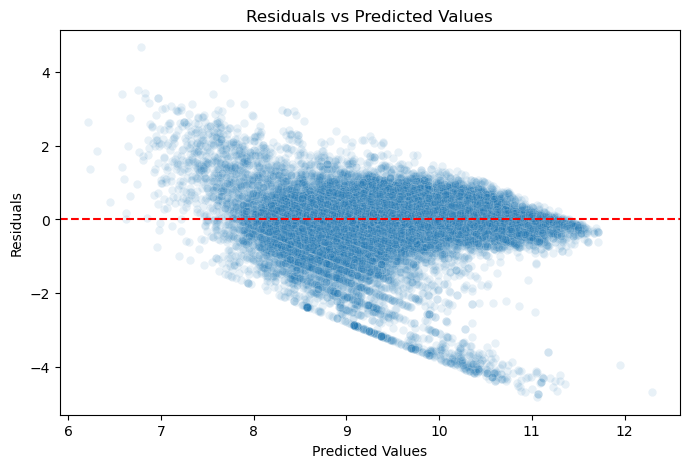

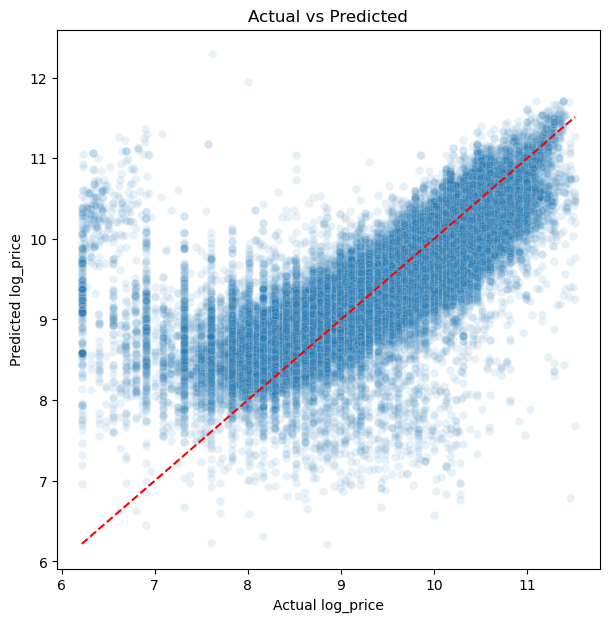

,feature,VIF
0,car_age,5.29
1,odometer_per_year,3.93
2,condition_score,1.60
3,cylinders_numeric,8.83
4,cylinders_missing,1.87
5,is_luxury,1.22


In [74]:
# Explore concepts like shape of residuals, VIF, etc (just exploring to learn though this was not covered in the course)

train_residuals = y_train - train_preds
test_residuals = y_test - test_preds

plt.figure(figsize=(10, 5))
sns.histplot(
    test_residuals,
    bins=60,
    kde=True
)

plt.title("Distribution of Test Residuals")
plt.xlabel("Residual")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=test_preds,
    y=test_residuals,
    alpha=0.1
)
plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()

plt.figure(figsize=(7, 7))

sns.scatterplot(
    x=y_test,
    y=test_preds,
    alpha=0.1
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)
plt.xlabel("Actual log_price")
plt.ylabel("Predicted log_price")
plt.title("Actual vs Predicted")

plt.show()


#VIF Calc

vif_features = cars[
    [
        "car_age",
        "odometer_per_year",
        "condition_score",
        "cylinders_numeric",
        "cylinders_missing",
        "is_luxury"
    ]
]

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_table = pd.DataFrame()
vif_table["feature"] = vif_features.columns
vif_table["VIF"] = [
    variance_inflation_factor(
        vif_features.values,
        i
    )
    for i in range(vif_features.shape[1])
]

display(vif_table)


# notes

1) Residual distribution plot indicates good bell shapeg curve, except for longer tail. Log transformation has helped to have a faily symmetric curve

2) While residuals across the predicted values aren't showing specific shape, it does have some changing pattern like a funnel as prediction range changes. It is an indication that there is error variance may not be constant

3) Also, residuals are compressed at high predictions indicating that the model maybe good with expensive vehicles

4) Actual vs Predicted plot shows an upward trend with stronger aligment around the diagnal. Looks like this base model might be a regression toward the mean. So cheap cars may get slight overpriced prediction, while the expensive cars get lower predicted price. Maybe it is worth trying complex models like Polynomial regression or other nonlinear models

5) While car_age feature is having modertate VIF, still not too bad (maybe influenced by another derived variable odometer per year, which is a ratio involving age), but we have to keep a closer watch on cyliners_numeric, as it has highest VIF. Moving along, testing regulairzation and ridge regression may help with this.

# Next Steps - Continue to optimize this base model with following techniques

1) Polynomial Regression → test nonlinear relationships
2) Ridge Regression → handle multicollinearity
3) Lasso Regression → feature selection + regularization
4) Sequential Feature Selection → explicit subset optimization
5) Hyperparameter tuning → optimize complexity

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.